# III - Exploration du CSV : Dynamouv, vrais chapitres et chronologie

Ce notebook :

1. **Explore** le CSV des triptyques :
   - nombre de verbes Dynamouv
   - répartition par **vrais chapitres**, reconstruits à partir du `.txt`
   - lemmes Dynamouv les plus fréquents

2. **Prépare dès le début un CSV enrichi** :
   - on lit le `.txt`
   - on repère les séparations de chapitres
   - on rattache chaque phrase / triptyque à son chapitre
   - on sauvegarde un CSV enrichi avec cette information


In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1) Paramètres

In [2]:
INPUT_CSV = "../results/csv_triptyques/triptyques_tdm.csv"
INPUT_TXT = "../data/TDM/1872_Verne-Jules_Le-tour-du-monde-en-quatre-vingts-jours.txt"
OUTPUT_DIR = "../results/exploration"
OUTPUT_CSV_ENRICHI = INPUT_CSV

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

print("INPUT_CSV        :", Path(INPUT_CSV).resolve())
print("INPUT_TXT        :", Path(INPUT_TXT).resolve())
print("OUTPUT_DIR       :", Path(OUTPUT_DIR).resolve())
print("OUTPUT_CSV_ENRICHI:", Path(OUTPUT_CSV_ENRICHI).resolve())


INPUT_CSV        : C:\Users\arnod\stage_lattice\Model_TDM\results\csv_triptyques\triptyques_tdm.csv
INPUT_TXT        : C:\Users\arnod\stage_lattice\Model_TDM\data\TDM\1872_Verne-Jules_Le-tour-du-monde-en-quatre-vingts-jours.txt
OUTPUT_DIR       : C:\Users\arnod\stage_lattice\Model_TDM\results\exploration
OUTPUT_CSV_ENRICHI: C:\Users\arnod\stage_lattice\Model_TDM\results\csv_triptyques\triptyques_tdm.csv


## 2) Charger le CSV et reconstruire les vrais chapitres à partir du `.txt`

Points importants :
- le CSV contient **une ligne par triptyque**
- pour compter les verbes, on fabrique aussi une table de **verbes uniques**
- un verbe Dynamouv est ici défini par :
  - `Annotation_verbe_col9 == "VERB"`
- les **vrais chapitres** sont reconstruits depuis le `.txt`
  - ici, les chapitres correspondent à des blocs séparés par **au moins quatre sauts de ligne** => spécifique à TDM donc il faut trouver une facon ou l'on peut le faire pour tous


In [3]:
df = pd.read_csv(INPUT_CSV)

# ordre textuel
sort_cols = [c for c in ["Sentence_index", "ID_verbe", "ID_objet"] if c in df.columns]
df = df.sort_values(sort_cols, kind="stable").reset_index(drop=True)
df["triplet_order"] = np.arange(1, len(df) + 1)

# booléen Dynamouv
df["is_dynamouv"] = df["Annotation_verbe_col9"].fillna("").eq("VERB")

# clé d'occurrence verbale unique (pour éviter les doublons dus aux objets multiples)
df["verb_occ_key"] = (
    df["Sentence_index"].astype(str) + "_"
    + df["ID_verbe"].astype(str)
)

verbs = (
    df.drop_duplicates("verb_occ_key")
      .copy()
      .reset_index(drop=True)
)

verbs["verb_order"] = np.arange(1, len(verbs) + 1)
verbs["is_dynamouv"] = verbs["Annotation_verbe_col9"].fillna("").eq("VERB")

# ---------- Reconstruction des chapitres depuis le .txt ----------
txt = Path(INPUT_TXT).read_text(encoding="utf-8")

# Les chapitres du fichier texte sont séparés par de grands blancs (>= 4 sauts de ligne)
chapter_blocks = re.split(r'(?:\n\s*){4,}', txt.strip())

def normalize_for_match(s):
    s = str(s).lower()
    s = s.replace("\xa0", " ").replace("’", "'").replace("–", "-").replace("—", "-")
    s = re.sub(r"\s+", " ", s).strip()
    # normalisation agressive pour éviter les écarts de tokenisation du CSV
    s = re.sub(r"[^a-zà-ÿ0-9]+", "", s)
    return s

chapter_norm = [normalize_for_match(block) for block in chapter_blocks]

# table des phrases uniques
sent_df = (
    df[["Sentence_index", "Phrase"]]
    .drop_duplicates()
    .sort_values("Sentence_index")
    .reset_index(drop=True)
)

sentence_to_chapter = {}
current_chapter = 0

for _, row in sent_df.iterrows():
    sent_idx = int(row["Sentence_index"])
    phrase_norm = normalize_for_match(row["Phrase"])

    found = False
    for chap_i in range(current_chapter, len(chapter_norm)):
        if phrase_norm and phrase_norm in chapter_norm[chap_i]:
            sentence_to_chapter[sent_idx] = chap_i + 1
            current_chapter = chap_i
            found = True
            break

    if not found:
        sentence_to_chapter[sent_idx] = pd.NA

df["chapter"] = df["Sentence_index"].map(sentence_to_chapter)
verbs["chapter"] = verbs["Sentence_index"].map(sentence_to_chapter)

# sauvegarde du CSV enrichi dès le début
df.to_csv(OUTPUT_CSV_ENRICHI, index=False, encoding="utf-8")

print("Nombre de chapitres détectés dans le .txt :", len(chapter_blocks))
print("Phrases sans chapitre attribué :", int(df[['Sentence_index','chapter']].drop_duplicates()['chapter'].isna().sum()))
print("CSV enrichi sauvegardé :", Path(OUTPUT_CSV_ENRICHI).resolve())

df.head()


Nombre de chapitres détectés dans le .txt : 37
Phrases sans chapitre attribué : 0
CSV enrichi sauvegardé : C:\Users\arnod\stage_lattice\Model_TDM\results\csv_triptyques\triptyques_tdm.csv


,Phrase,Sujet,Verbe,Objet,Dep_sujet,Dep_verbe,Dep_objet,ID_sujet,ID_verbe,ID_objet,...,Head_verbe,Annotation_verbe_col8,Annotation_verbe_col9,Num_phrase,Num_paragr,Sentence_index,triplet_order,is_dynamouv,verb_occ_key,chapter
0,"En l’ année 1872, la maison portant le numéro ...",NaN,portant,le numéro 7 de Saville - row Burlington Gardens,NaN,acl,obj,NaN,8,10.0,...,7,_,_,1,1,1,1,False,1_8,1
1,"En l’ année 1872, la maison portant le numéro ...",Sheridan,mourut,en 1814,nsubj,acl:relcl,obl:mod,23.0,24,26.0,...,20,_,_,1,1,1,2,False,1_24,1
2,"En l’ année 1872, la maison portant le numéro ...",la maison maison,habitée,En l’ année 1872,nsubj:pass,root,obl:mod,7.0,30,3.0,...,0,_,_,1,1,1,3,False,1_30,1
3,"En l’ année 1872, la maison portant le numéro ...",la maison maison,habitée,par Phileas Fogg esq.,nsubj:pass,root,obl:agent,7.0,30,32.0,...,0,_,_,1,1,1,4,False,1_30,1
4,"En l’ année 1872, la maison portant le numéro ...",la maison maison,habitée,l’ un des membres les plus singuliers et les p...,nsubj:pass,root,obl:mod,7.0,30,39.0,...,0,_,_,1,1,1,5,False,1_30,1


## 3) Vrais chapitres

In [4]:
chapter_counts = (
    verbs.groupby("chapter", as_index=False)
         .agg(
             n_verbs=("verb_occ_key", "count"),
             n_dynamouv=("is_dynamouv", "sum")
         )
)

chapter_counts["share_dynamouv"] = chapter_counts["n_dynamouv"] / chapter_counts["n_verbs"]

chapter_counts.head()


,chapter,n_verbs,n_dynamouv,share_dynamouv
0,1,201,6,0.029851
1,2,163,1,0.006135
2,3,301,6,0.019934
3,4,159,4,0.025157
4,5,117,2,0.017094


## 4) Exploration simple

### 4.1 Nombre de verbes Dynamouv par chapitre


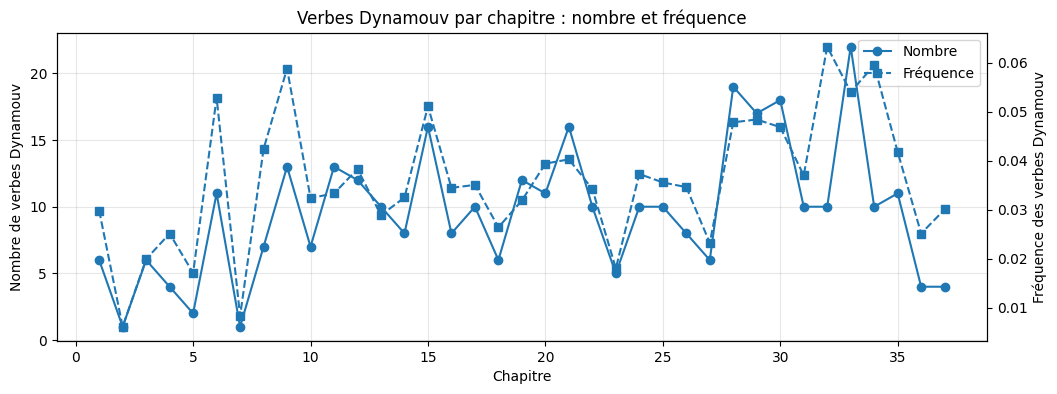

In [5]:
fig, ax1 = plt.subplots(figsize=(12, 4))

line1 = ax1.plot(
    chapter_counts["chapter"],
    chapter_counts["n_dynamouv"],
    marker="o",
    label="Nombre"
)
ax1.set_xlabel("Chapitre")
ax1.set_ylabel("Nombre de verbes Dynamouv")
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
line2 = ax2.plot(
    chapter_counts["chapter"],
    chapter_counts["share_dynamouv"],
    marker="s",
    linestyle="--",
    label="Fréquence"
)
ax2.set_ylabel("Fréquence des verbes Dynamouv")

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper right")

plt.title("Verbes Dynamouv par chapitre : nombre et fréquence")
plt.show()

### 4.2 verbes Dynamouv les plus fréquents


In [6]:
top_dyn = (
    verbs.loc[verbs["is_dynamouv"]]
         .groupby(["Lemme_verbe", "Annotation_verbe_col8"], as_index=False)
         .size()
         .sort_values("size", ascending=False)
         .head(20)
)

top_dyn


,Lemme_verbe,Annotation_verbe_col8,size
3,aller,Dpt au sens large,23
6,arriver,Dpt au sens large,21
33,gagner,Dpt au sens large,21
42,passer,Dpt au sens large,21
46,quitter,Dpt au sens large,18
74,échapper,Dpt au sens large,13
7,atteindre,Dpt au sens large,12
69,venir,Dpt au sens large,11
16,descendre,Dpt au sens large,10
68,traverser,Dpt au sens large,9


## 5) Exporter csv de verbes dynamouv par chapitres 

In [7]:

# Garder seulement les verbes Dynamouv
df_dyn = df[df["Annotation_verbe_col9"].fillna("").eq("VERB")].copy()

cols = ["Phrase", "Sujet", "Verbe", "Objet", "Annotation_verbe_col8", "chapter"]
existing = [c for c in cols if c in df_dyn.columns]

df_out = df_dyn[existing].copy().rename(columns={
    "Annotation_verbe_col8": "type_deplacement",
    "chapter": "chapitre"
})

df_out.to_csv(Path(OUTPUT_DIR)/ "chapter_triptyques_dynamouv.csv", index=False, encoding="utf-8")

chapter_counts.to_csv(Path(OUTPUT_DIR)/ "chapter_counter_dynamouv.csv", index=False, encoding="utf-8")


Conllu utilisé : ..\results\conllu_dynamouv\1872_Verne-Jules_Le-tour-du-monde-en-quatre-vingts-jours.conllu


Nombre total de triptyques : 13047
Nombre de triptyques avec personnage PER : 7783
Nombre de triptyques avec lieu FAC/LOC : 1032
Nombre de triptyques avec personnage ET lieu : 390


CSV sauvegardé : C:\Users\arnod\stage_lattice\Model_TDM\results\exploration\triptyques_avec_personnage_et_lieu_PAR_TRIPTYQUE.csv


,Phrase,Sujet,Verbe,Objet,personnages_sujet,personnages_objet,lieux_sujet,lieux_objet,personnages_triptyque,lieux_triptyque,types_lieux_triptyque
3,"En l’ année 1872, la maison portant le numéro ...",la maison maison,habitée,par Phileas Fogg esq.,[],[3],[la maison],[],[3],[la maison],[FAC]
25,Son nom n’ avait jamais retenti dans un collèg...,Son nom,retenti,dans un collège d’ avocats ni au Temple ni à L...,[3],[],[],"[au temple, lincoln’ s - inn, gray’ s - inn]",[3],"[au temple, lincoln’ s - inn, gray’ s - inn]",[FAC]
26,Jamais il ne plaida ni à la Cour du chancelier...,il,plaida,ni à la Cour du chancelier ni au Banc de la Re...,[3],[],[],[la reine],[3],[la reine],[FAC]
88,Ceux qui avaient l’ honneur de le connaître un...,il,venir,de sa maison au club,[1],[1],[],"[sa maison, au club]",[1],"[sa maison, au club]",[FAC]
108,Phileas Fogg vivait seul dans sa maison de Sav...,Phileas Fogg,vivait,dans sa maison de Saville - row,[3],[3],[],"[sa maison de saville - row, saville - row]",[3],"[sa maison de saville - row, saville - row]",[FAC]
128,"Sur vingt-quatre heures, il en passait dix à s...",il,passait,à son domicile,[3],[3],[],[son domicile],[3],[son domicile],[FAC]
134,"S’ il se promenait, c’ était invariablement, d...",il,promenait,dans la salle d’ entrée ou sur la galerie circ...,[3],[],[],"[la salle d’ entrée parquetée en marqueterie, ...",[3],"[la salle d’ entrée parquetée en marqueterie, ...",[FAC]
187,"À onze heures et demie sonnant, Mr. Fogg devai...",Mr. Fogg,quitter,la maison,[1],[],[],[la maison],[1],[la maison],[FAC]
189,"À onze heures et demie sonnant, Mr. Fogg devai...",Mr. Fogg,rendre,au Reform,[1],[],[],[au reform - club],[1],[au reform - club],[FAC]
190,"À onze heures et demie sonnant, Mr. Fogg devai...",Mr. Fogg,rendre,-,[1],[],[],[au reform - club],[1],[au reform - club],[FAC]
